# Quickview Notebook

Welcome! This IPython notebook provides a quick look at short segments of data from the <a href='https://gwosc.org/'>Gravitational Wave Open Science Center</a>

* Set the GPS time (t0) and detector in the first cell
* Click "Run All" in the cell menu at the top
* Your plots will appear below

v0.10; December 2024

## Set Parameters

* [GPS time](https://gwosc.org/gps) of the data of interest ([Learn more](https://www.google.com/search?q=What+is+gps+time))
* Detector could be H1 (LIGO Hanford), L1 (LIGO Livingston), or V1 (Virgo)

In [7]:
# -- Set a GPS time:
t0 = 1126259462.4    # -- GW150914

#-- Choose detector as H1, L1, or V1
detector = 'H1'

You might try some of these examples times in the H1 detector:
<pre>
t0 = 1126259462.4    # -- GW150914
t0 = 1187008882.4    # -- GW170817
t0 = 933200215       # -- Loud hardware injection
t0 = 1132401286.33   # -- Koi Fish Glitch
</pre>

### Import some packages

In [8]:
import requests, os
import matplotlib.pyplot as plt
import numpy as np
%config InlineBackend.figure_format = 'retina'

try:
    from gwpy.timeseries import TimeSeries
except:
    ! pip install -q "gwpy==3.0.9"
    ! pip install -q "matplotlib==3.7.3"
    ! pip install -q "astropy==6.1.4"
    from gwpy.timeseries import TimeSeries

import pickle

def unpickle_me_this(filename: str, absolute_path=False):
    if absolute_path:
        file = open(filename, 'rb')
    else:
        file = open(filename, 'rb')
    data = pickle.load(file)
    file.close()
    return data

# -- Turn on interactive plotting
plt.ion()

### Query and download data

In [9]:
strain = TimeSeries.fetch_open_data(detector, t0-16, t0+16)

# strain = unpickle_me_this("GW150914_strain.pickle")
zero_level = 1126259446
times = np.array(strain.times)-zero_level
data = strain.value
onset = t0 - zero_level

### Plot the raw time-series data

Obviously a gravitational wave lol.


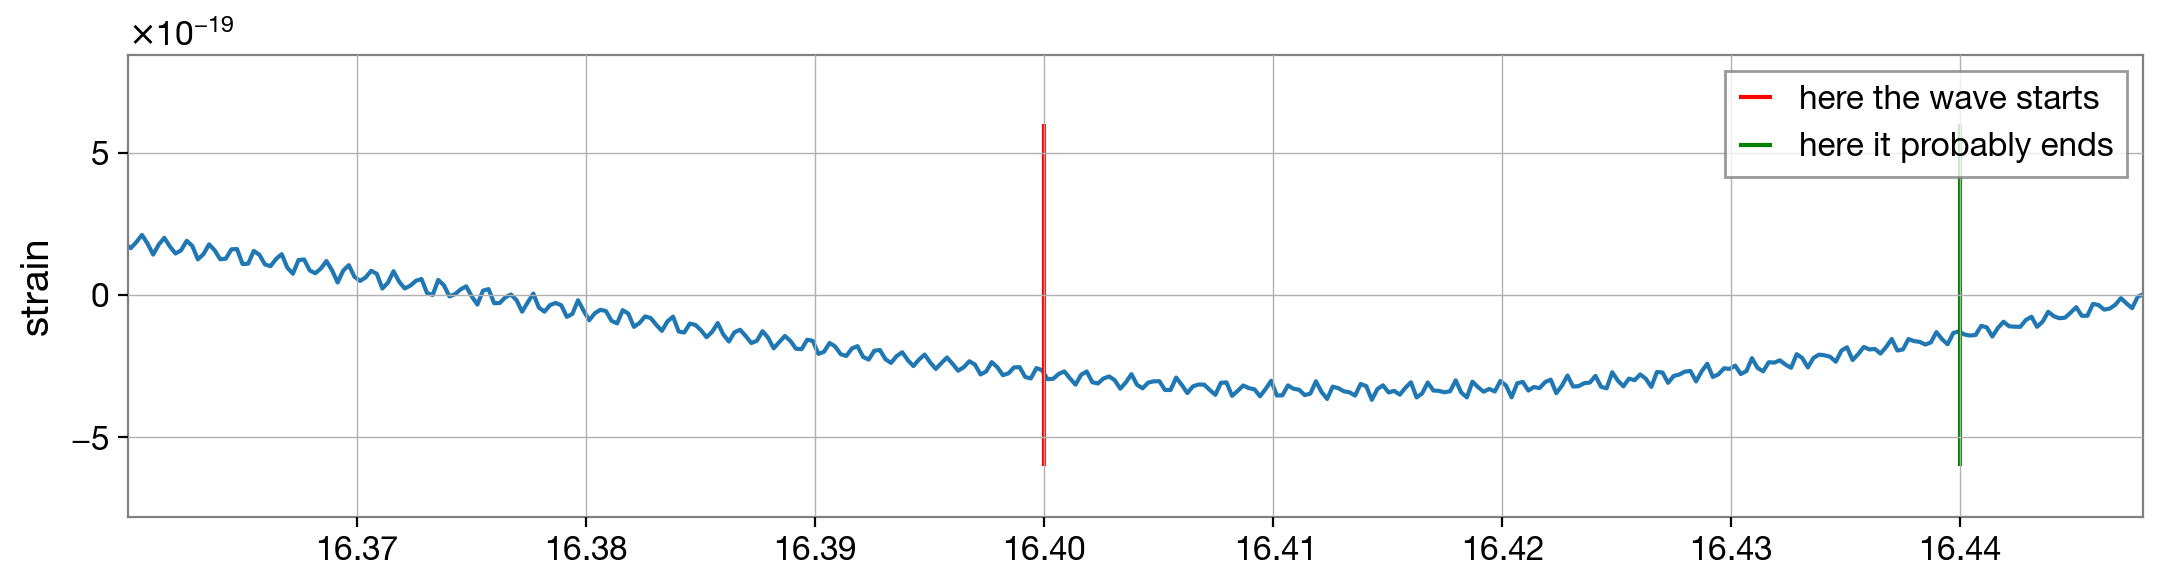

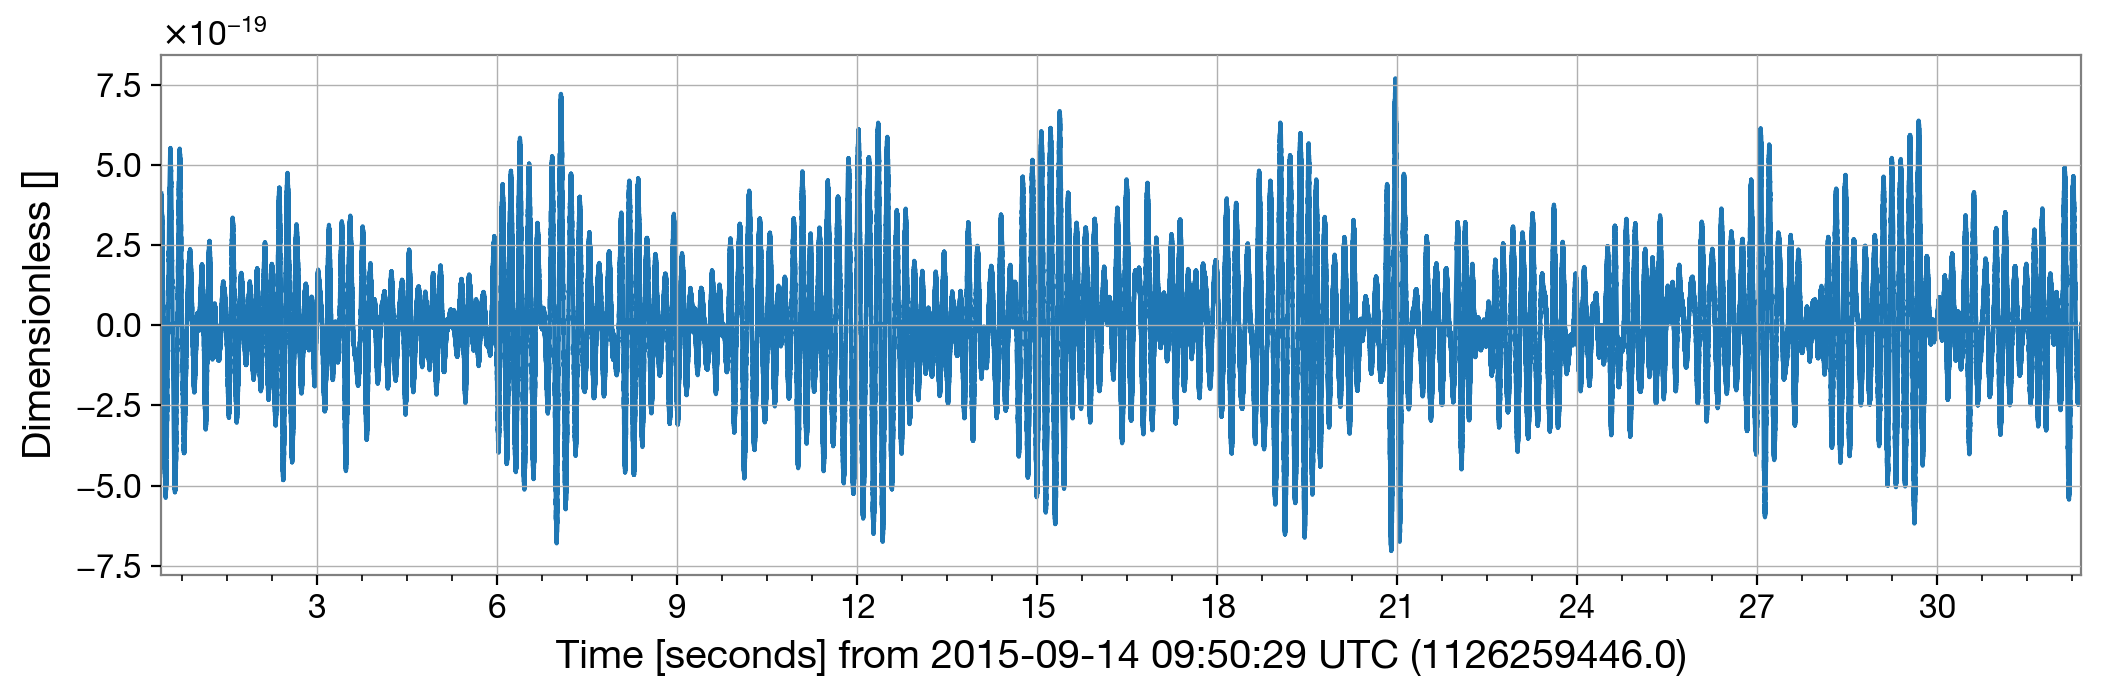

In [10]:
fig = plt.figure(figsize=(13,3))
plt.plot(times, data)
plt.ylabel("strain")
duration = 0.04
plt.xlim(onset-duration,onset+duration*1.2)
plt.vlines(onset, -6e-19,6e-19, label="here the wave starts", color="red")
plt.vlines(onset+duration, -6e-19,6e-19, label="here it probably ends", color="green")
plt.legend()
plt.show()

fig2 = strain.plot()
# plt.xlim(center+9,center+10)
plt.show()

### Plot the Amplitude Spectral Density (ASD)

The amplitude spectral density is one way to visualize the frequency-domain content of a time series signal.
 * [ASDs in the gwpy documentation](https://gwpy.github.io/docs/stable/signal/)
 * [ASDs in Wikipedia](https://en.wikipedia.org/wiki/Spectral_density)
 * [ASDs in the Frequency Domain Data video](https://labcit.ligo.caltech.edu/~jkanner/gwosc/intro-course/)

(1e-24, 1e-19)

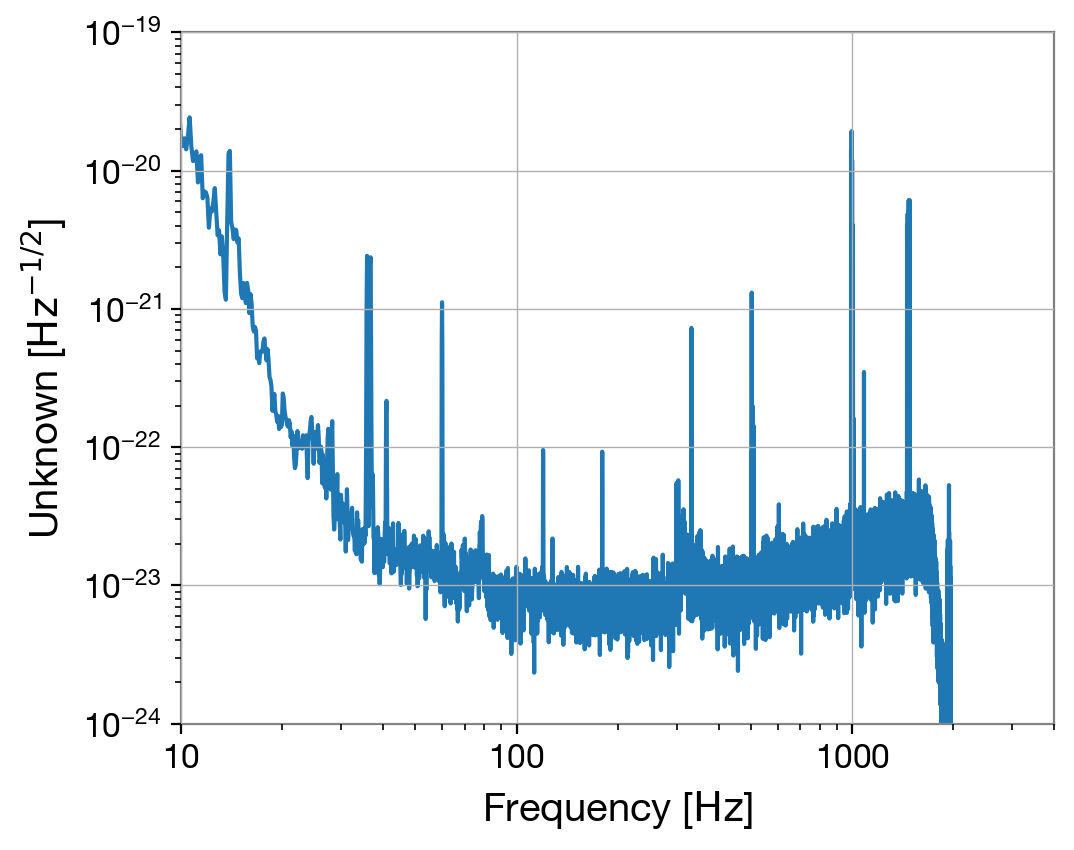

In [6]:
# -- Plot ASD
fig2 = strain.asd(fftlength=8).plot()
plt.xlim(10,4000)
plt.ylim(1e-24, 1e-19)

### Whiten and band-pass the data

* Whitening is a process that re-weights a signal, so that all frequency bins have a nearly equal amount of noise.
* A band-pass filter uses both a low frequency cutoff and a high frequency cutoff, and only passes signals in the frequency band between these values.

See also:

 * [Whitening a TimeSeries](https://gwpy.github.io/docs/stable/examples/timeseries/whiten/#whitening-a-timeseries)
 * [Signal Processing Tutorial](https://gwfilter.streamlit.app)
 * [Finding Signals in Noise video](https://labcit.ligo.caltech.edu/~jkanner/gwosc/intro-course/)


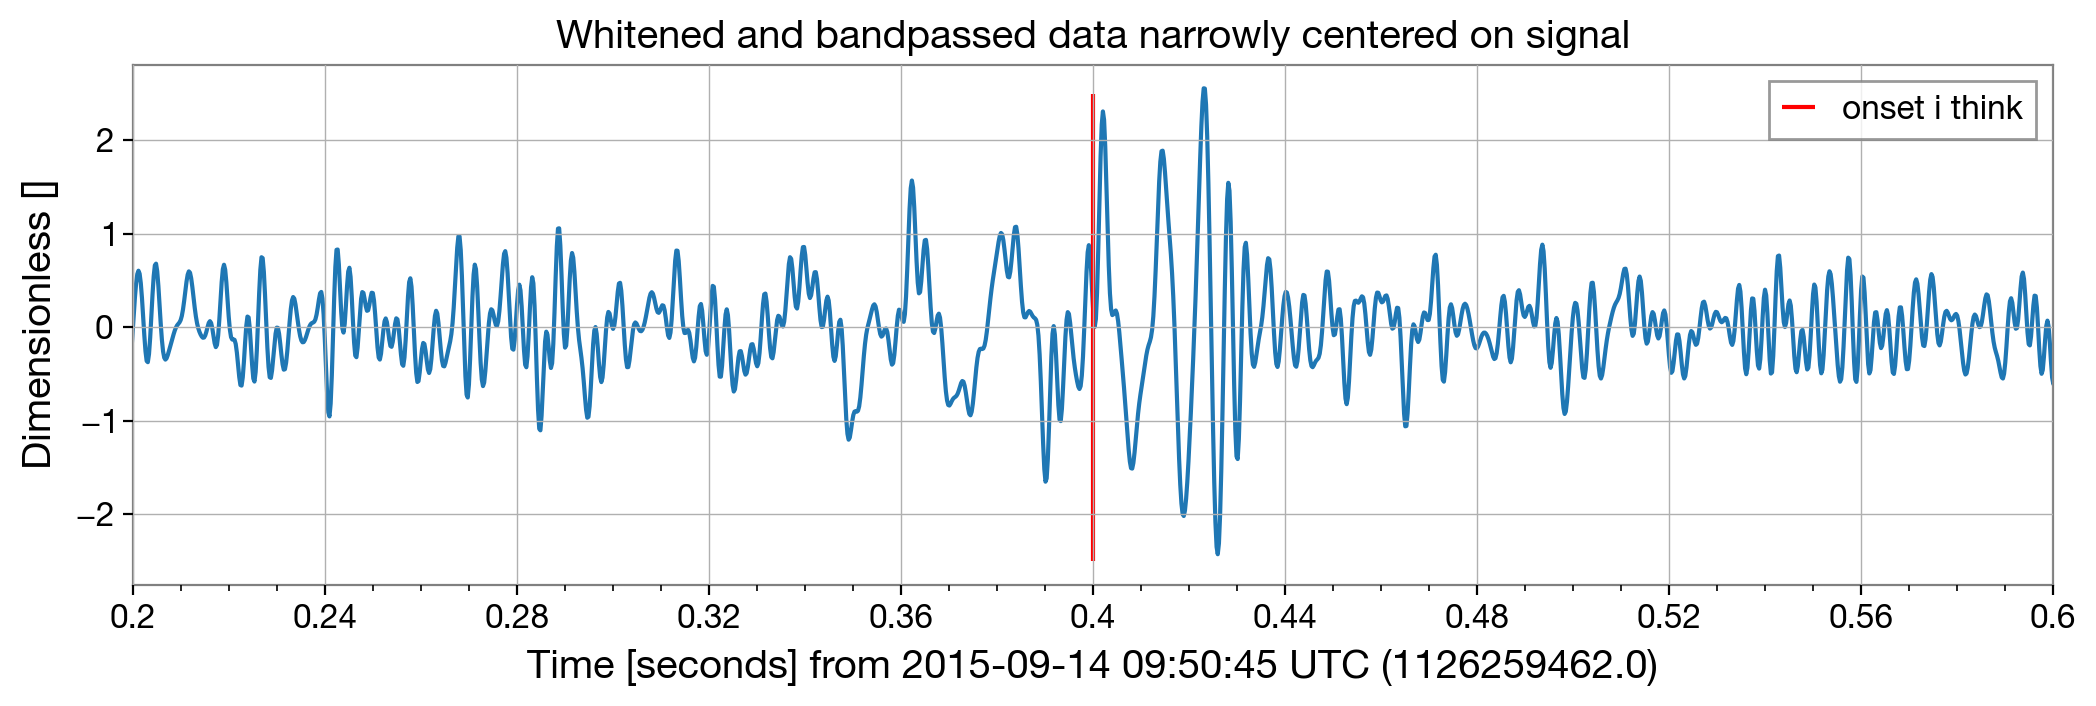

In [11]:
# -- Whiten and bandpass data
white_data = strain.whiten()
bp_data = white_data.bandpass(30, 400)
fig3 = bp_data.plot()
plt.title("Whitened and bandpassed data narrowly centered on signal")
plt.vlines(t0, -2.5, 2.5, label="onset i think", color="red")
plt.xlim(t0-0.2, t0+0.2)
plt.legend()

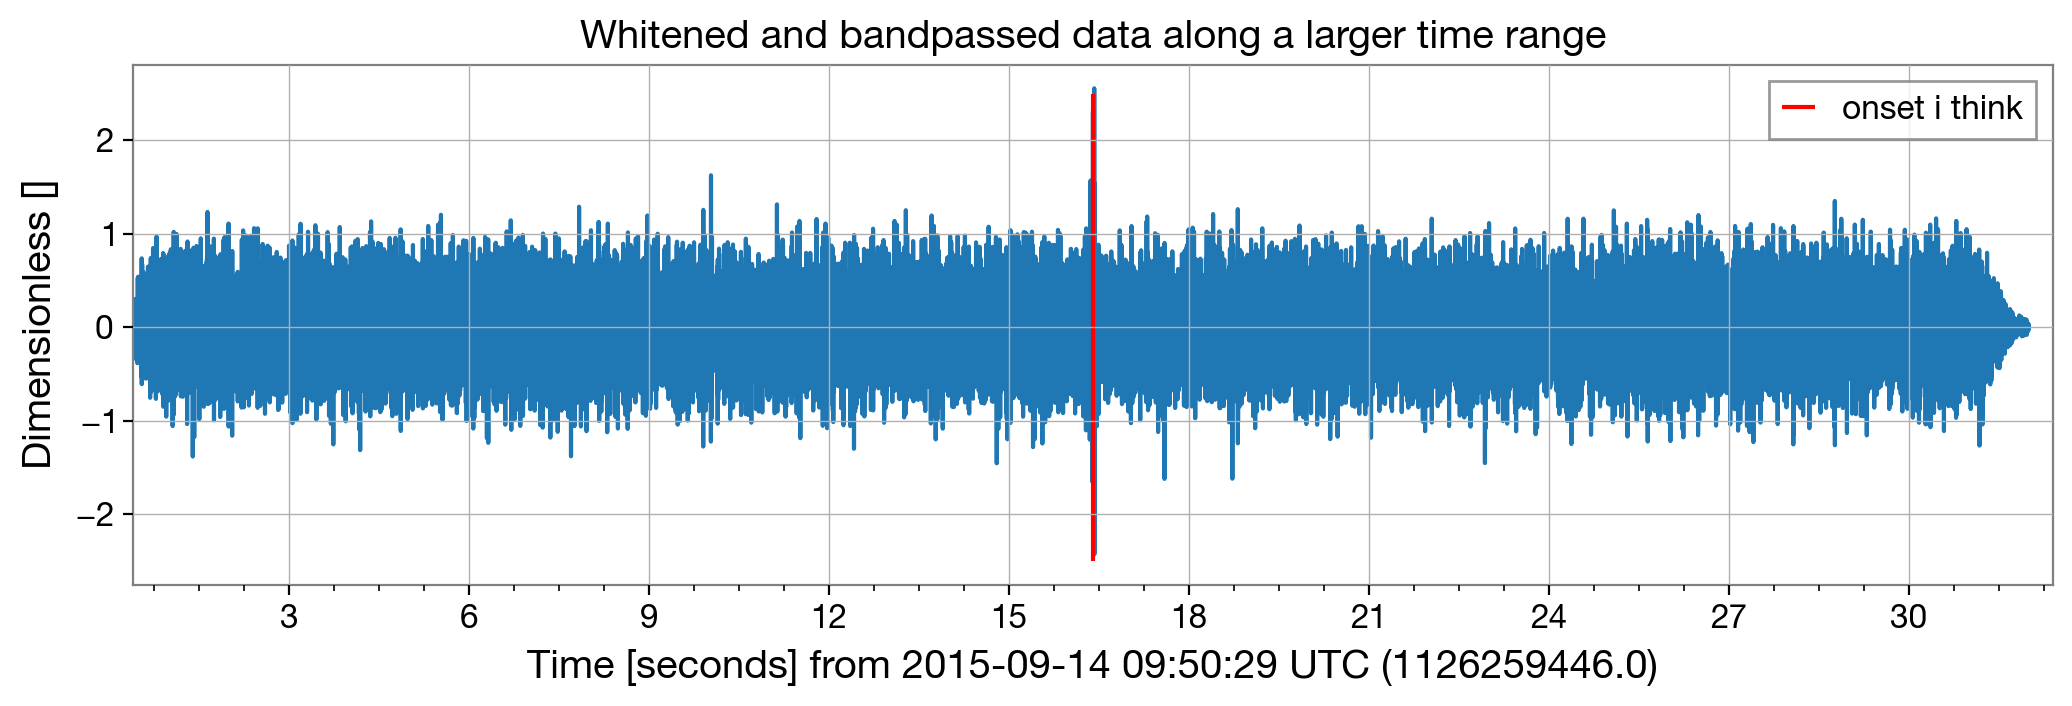

In [13]:
white_data = strain.whiten()
bp_data = white_data.bandpass(30, 400)
fig4 = bp_data.plot()
plt.title("Whitened and bandpassed data along a larger time range")
plt.vlines(t0, -2.5, 2.5, label="onset i think", color="red")
plt.xlim(t0-16, t0+16)
plt.legend()

### Plot a q-transform of the data

A Q-transform plot shows how a signal’s frequency changes with time.

* The x-axis shows time
* The y-axis shows frequency
* The color scale shows the amount of “energy” or “signal power” in each time-frequency pixel.

A parameter called “Q” refers to the quality factor. A higher quality factor corresponds to a larger number of cycles in each time-frequency pixel.

* [Q-transform in gwpy](https://gwpy.github.io/docs/latest/examples/timeseries/qscan/)
* [Q-transform in Wikipedia](https://en.wikipedia.org/wiki/Constant-Q_transform)

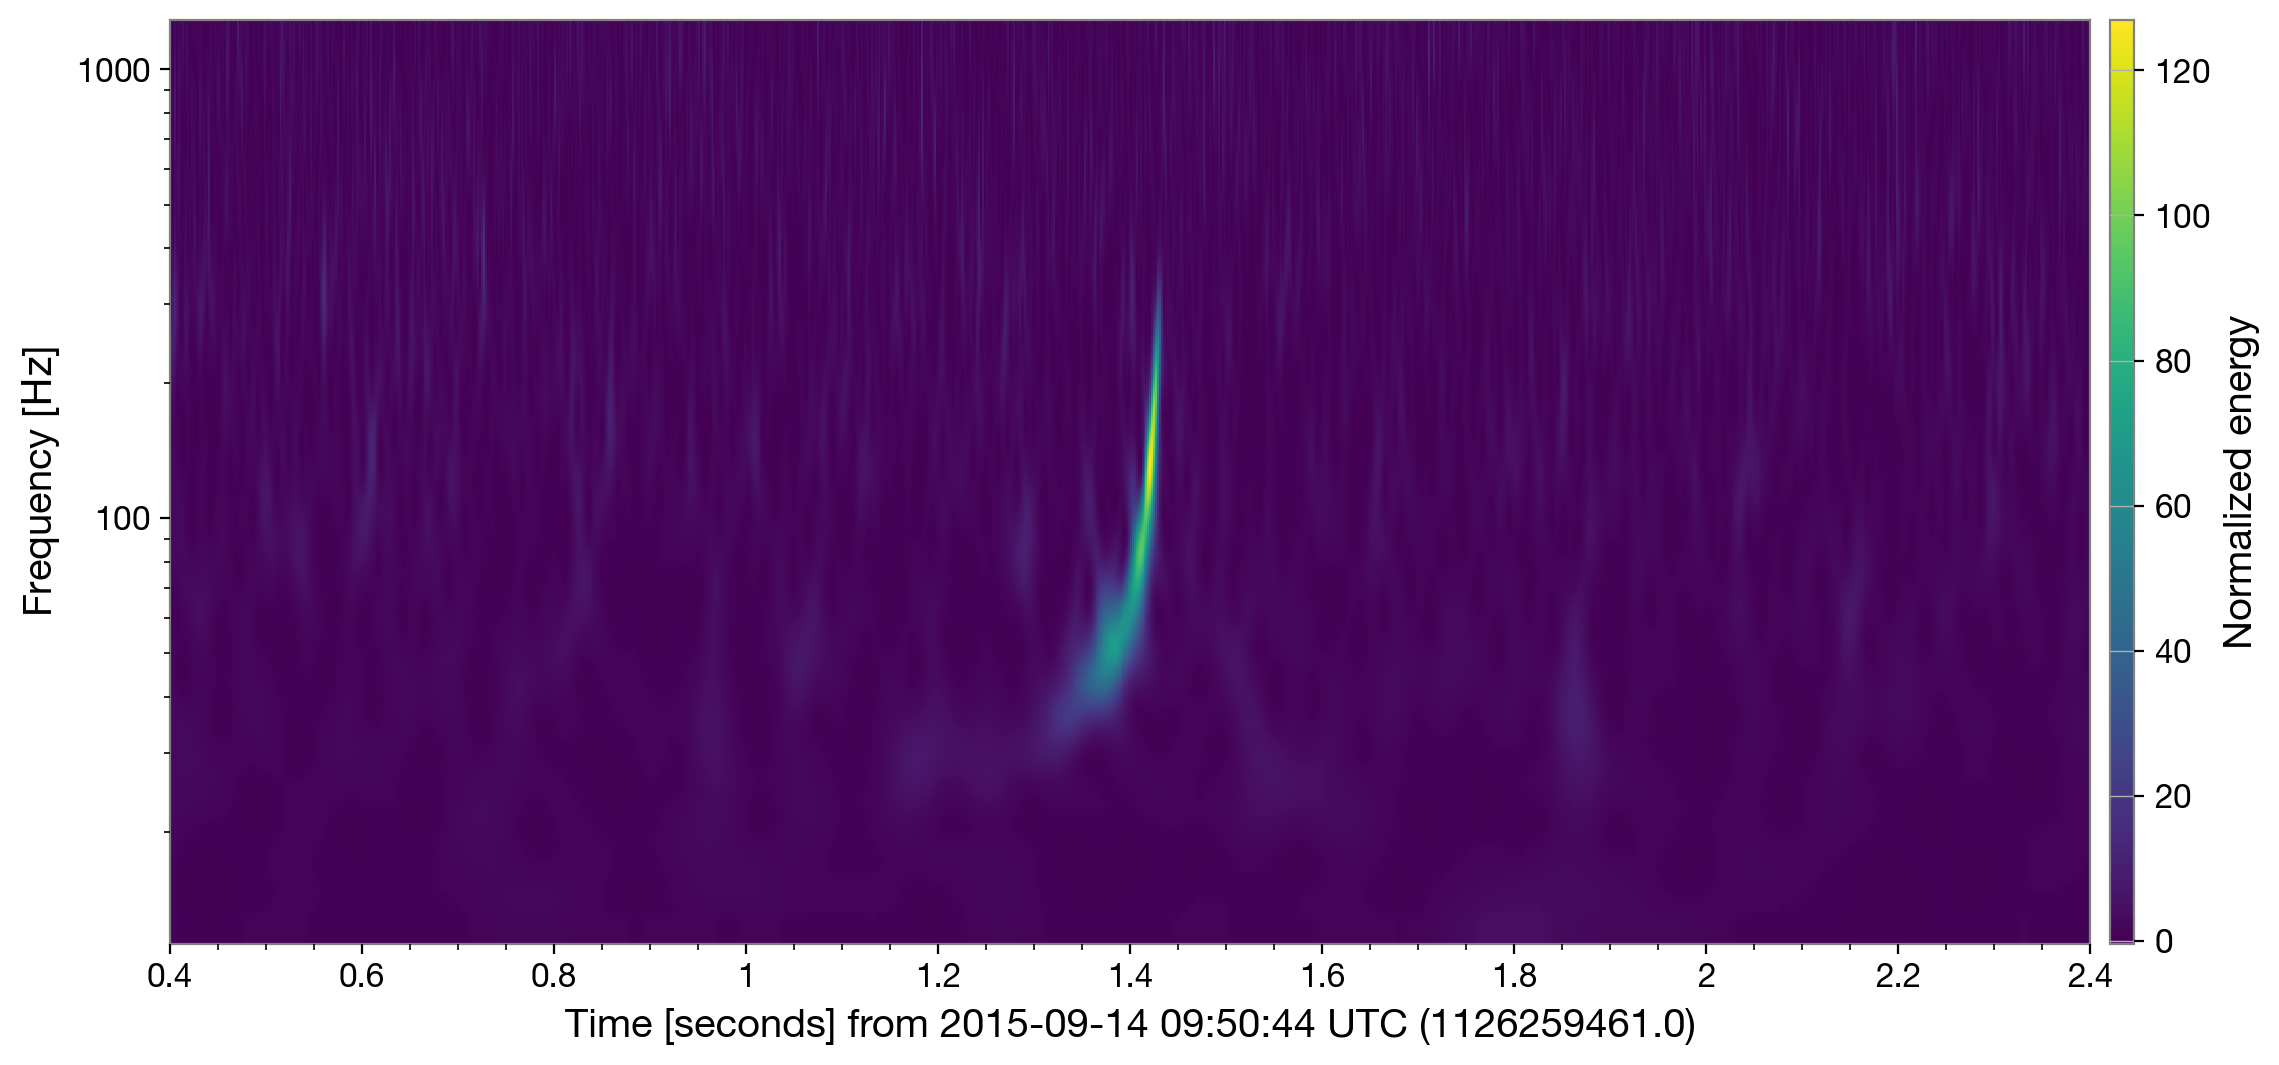

In [21]:
dt = 1  #-- Set width of q-transform plot, in seconds
hq = strain.q_transform(outseg=(t0-dt, t0+dt))
fig4 = hq.plot()
ax = fig4.gca()
ax.grid(False)
ax.set_yscale('log')
try: fig4.colorbar(label="Normalized energy")
except: pass